# 09 — Replikacija u korelacijskom prostoru (HRP/HERC/NCO)

Faza 1, taskovi **F1.5** (integracija u walk-forward) i **F1.6**
(replikacijska tablica). Vlastite implementacije iz `src/hierarchical.py`
puštaju se kroz isti klizni prozor kao benchmark portfelji: **isti
presjek univerzuma**, **ista Ledoit–Wolf Σ** (jednom po prozoru, dijeli
se među alokatorima), isti `w_max`, isti format izlaza. Jedina razlika
prema benchmarcima su same težine.

Alokatori (korelacijski prostor, stabla iz F1.1b):

- `hrp_corr_single` — jednostruka veza, **vjerna replikacija López de
  Prada (2016)**; isključivo replikacijski red.
- `hrp_corr_ward` — Wardova veza; nositelj kontrolirane usporedbe
  prostora (K1).
- `herc_corr` — Wardova veza, rez stabla na K (Raffinot 2018).
- `nco_corr` — Wardova veza, particija rezom stabla na K (López de
  Prado 2019).


In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.WARNING, format="%(asctime)s %(levelname)s %(message)s")

from src.backtest import (
    HIERARCHICAL_PORTFOLIO_NAMES,
    generate_rolling_windows,
    run_hierarchical_walk_forward,
)
from src.evaluation import (
    apply_costs,
    risk_metrics,
    sharpe_ratio,
    turnover_per_window,
)
from src.utils import (
    FIGURES_DIR,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    TC_BPS,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()


In [2]:
monthly_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0, parse_dates=True
)
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
factor_clusters = pd.read_csv(PROCESSED_DATA_DIR / "factor_clusters.csv")
correlation_clusters = pd.read_csv(PROCESSED_DATA_DIR / "correlation_clusters.csv")
metadata = pd.read_csv(PROCESSED_DATA_DIR / "metadata.csv")
membership = pd.read_csv(
    PROCESSED_DATA_DIR / "membership.csv",
    parse_dates=["start_date", "end_date"],
)
factors = pd.read_csv(
    PROCESSED_DATA_DIR / "factors.csv", index_col=0, parse_dates=True
)

windows = generate_rolling_windows()
print("Prozori:", len(windows), "|", windows[0].label, "->", windows[-1].label)


Prozori: 21 | 2004-12 -> 2024-12


## 9.1 F1.5 — Unaprijedni hod hijerarhijskih alokatora

Broj klastera `K` za HERC i NCO dolazi iz primarne procedure odabira K
(F1.0): najviša prosječna silueta kroz prozore, bez dodatnih uvjeta
(riješeno pitanje 8). Čita se iz `02_silhouette_by_k.csv` da ne bi bio
hardkodiran.


In [3]:
silhouette = pd.read_csv(TABLES_DIR / "02_silhouette_by_k.csv")
K = int(silhouette.loc[silhouette["mean_silhouette"].idxmax(), "k"])
print("Primarni K (argmax prosječne siluete):", K)

hier = run_hierarchical_walk_forward(
    monthly_returns=monthly_returns,
    factor_exposures=factor_exposures,
    factor_clusters=factor_clusters,
    correlation_clusters=correlation_clusters,
    metadata=metadata,
    windows=windows,
    k=K,
    tree_space="correlation",
    membership=membership,
)

weights_panel = hier["weights_panel"]
returns_panel = hier["port_returns_panel"]
status_panel = hier["portfolio_status"]

weights_panel.to_csv(TABLES_DIR / "09_weights_panel_hierarchical.csv", index=False)
returns_panel.to_csv(
    TABLES_DIR / "09_port_returns_panel_hierarchical.csv", index_label="date"
)
status_panel.to_csv(TABLES_DIR / "09_portfolio_status_hierarchical.csv", index=False)

print("Panel prinosa:", returns_panel.shape, "| stupci:", returns_panel.columns.tolist())
print("Mjeseci po alokatoru:")
print(returns_panel.notna().sum())


Primarni K (argmax prosječne siluete): 3


Panel prinosa: (252, 4) | stupci: ['hrp_corr_single', 'hrp_corr_ward', 'herc_corr', 'nco_corr']
Mjeseci po alokatoru:
portfolio
hrp_corr_single    252
hrp_corr_ward      252
herc_corr          252
nco_corr           252
dtype: int64


In [4]:
# Provjera kriterija prihvaćanja F1.5: status bez neobjašnjenih 'failed'
# i stupac capped_weight_share po (portfelj, prozor).
assert "capped_weight_share" in status_panel.columns
failed = status_panel.loc[status_panel["status"].str.startswith("failed")]
assert failed.empty, f"Neobjašnjeni neuspjesi:\n{failed}"
assert (returns_panel.notna().sum() >= 240).all()

print("Statusi:", status_panel["status"].unique().tolist())
print("\nUdio težine na capu (capped_weight_share) po alokatoru:")
print(
    status_panel.groupby("portfolio")["capped_weight_share"]
    .agg(["mean", "max"])
    .round(4)
)


Statusi: ['ok']

Udio težine na capu (capped_weight_share) po alokatoru:
                   mean   max
portfolio                    
herc_corr        0.0133  0.24
hrp_corr_single  0.0000  0.00
hrp_corr_ward    0.0000  0.00
nco_corr         0.6676  0.98


## 9.2 F1.6 — Replikacijska tablica

OOS godišnja volatilnost, Sharpe (bruto i neto na 10 bps), maksimalni
drawdown, prosječni jednostrani obrtaj i `n_months` za benchmark obitelj
(1/N, min_var i čista `factor_neutral_eε` obitelj — zaključana odluka 10,
izmjena 2026-06-12) i četiri hijerarhijska alokatora. Trošak se obračunava
na refit obrtaj i skida s prvog mjeseca svake testne godine
(`turnover_per_window` / `apply_costs`).


In [5]:
# Benchmark obitelj (1/N, min_var, factor_neutral_eε) iz Faze 1.
benchmark_panel = pd.read_csv(
    TABLES_DIR / "05_port_returns_panel_extended.csv", index_col=0, parse_dates=True
)
gross_panel = pd.concat([benchmark_panel, returns_panel], axis=1)

# Dugi paneli težina za obrtaj: benchmark (1/N, min_var), factor_neutral i hijerarhijski.
weights_core = pd.read_csv(TABLES_DIR / "weights_panel.csv")
weights_factor_neutral = pd.read_csv(TABLES_DIR / "05_weights_panel_factor_neutral.csv")
weights_all = pd.concat(
    [weights_core, weights_factor_neutral, weights_panel], ignore_index=True
)

turnover = turnover_per_window(weights_all)
net_panel = apply_costs(gross_panel, turnover, tc_bps=TC_BPS)
rf = factors["RF"]

row_order = [
    "equal_weight",
    "min_var",
    "factor_neutral_e0",
    "factor_neutral_e0.05",
    "factor_neutral_e0.1",
    "factor_neutral_e0.15",
    "hrp_corr_single",
    "hrp_corr_ward",
    "herc_corr",
    "nco_corr",
]

summary_rows = []
for name in row_order:
    if name not in gross_panel.columns:
        continue
    metrics = risk_metrics(gross_panel[name])
    avg_turnover = turnover.loc[turnover["portfolio"] == name, "turnover"].mean()
    summary_rows.append(
        {
            "portfolio": name,
            "ann_vol": metrics["ann_vol"],
            "sharpe_gross": sharpe_ratio(gross_panel[name], rf),
            "sharpe_net": sharpe_ratio(net_panel[name], rf),
            "max_drawdown": metrics["max_drawdown"],
            "turnover": float(avg_turnover),
            "n_months": int(metrics["n_months"]),
        }
    )

replication_summary = pd.DataFrame(summary_rows)
replication_summary.to_csv(TABLES_DIR / "09_replication_summary.csv", index=False)
print("Redaka:", len(replication_summary))
replication_summary.round(4)


Redaka: 10


,portfolio,ann_vol,sharpe_gross,sharpe_net,max_drawdown,turnover,n_months
0,equal_weight,0.1687,0.6062,0.6056,-0.5326,0.0941,252
1,min_var,0.1233,0.6321,0.6289,-0.4322,0.3770,252
2,factor_neutral_e0,0.1286,0.6496,0.6462,-0.4309,0.4093,252
3,factor_neutral_e0.05,0.1257,0.6544,0.6511,-0.4288,0.4004,252
4,factor_neutral_e0.1,0.1238,0.6549,0.6515,-0.4332,0.3968,252
5,factor_neutral_e0.15,0.1231,0.6541,0.6507,-0.4351,0.3933,252
6,hrp_corr_single,0.1409,0.6540,0.6523,-0.4768,0.2259,252
7,hrp_corr_ward,0.1414,0.6469,0.6452,-0.4881,0.2283,252
8,herc_corr,0.1491,0.5969,0.5944,-0.5122,0.3615,252
9,nco_corr,0.1248,0.6434,0.6396,-0.4331,0.4553,252


### Fusnote uz replikacijsku tablicu (obavezno, F1.6)

**(a)** `hrp_corr_single` je **vjerna replikacija izvornika** (López de
Prado 2016): jednostruka veza na d = √(½(1−ρ)) + kvazidijagonalizacija +
rekurzivna bisekcija. Ostaje **isključivo replikacijski red** — kontrolirana
usporedba prostora (Faza 3) ide preko `hrp_corr_ward` (Wardova veza u oba
kraka, korekcija K1), jer bi uključivanje jednostruke veze konfundiralo
metodu veze s prostorom hijerarhije.

**(b)** `nco_corr` koristi particiju **rezom hijerarhijskog stabla na K**
umjesto k-means particije iz izvornog rada (López de Prado 2019; riješeno
pitanje 7). K-means particija ostaje kao dodatna robusnost u Fazi 3 (F3.5).

Obje fusnote zapisane su i u `outputs/tables/09_replication_summary_notes.md`
(bilješka uz tablicu za izvještaj).


In [6]:
# Bilješka uz tablicu za izvještaj (obje obavezne fusnote F1.6).
notes = (
    "# Fusnote uz 09_replication_summary.csv\n\n"
    "(a) hrp_corr_single = vjerna replikacija izvornika (Lopez de Prado 2016, "
    "jednostruka veza); iskljucivo replikacijski red. Kontrolirana usporedba "
    "prostora ide preko hrp_corr_ward (Wardova veza u oba kraka, K1).\n\n"
    "(b) nco_corr particija = rez stabla na K umjesto k-meansa iz izvornog "
    "rada (Lopez de Prado 2019; rijeseno pitanje 7); k-means ostaje robusnost F3.5.\n"
)
(TABLES_DIR / "09_replication_summary_notes.md").write_text(notes, encoding="utf-8")
print(notes)


# Fusnote uz 09_replication_summary.csv

(a) hrp_corr_single = vjerna replikacija izvornika (Lopez de Prado 2016, jednostruka veza); iskljucivo replikacijski red. Kontrolirana usporedba prostora ide preko hrp_corr_ward (Wardova veza u oba kraka, K1).

(b) nco_corr particija = rez stabla na K umjesto k-meansa iz izvornog rada (Lopez de Prado 2019; rijeseno pitanje 7); k-means ostaje robusnost F3.5.



### Kumulativni rast

Univerzum je point-in-time (presjek na članstvo S&P 500 na `train_end`, PROJECT_SPEC §3.1) uz sanitaciju fizički nemogućih mjesečnih prinosa (`clip_implausible_returns`, pojas [-90 %, +300 %] → NaN), pa su raniji artefakti ponovo iskorištenih/delistanih tickera uklonjeni. Y-os je logaritamska radi usporedivosti kumulativnog rasta.

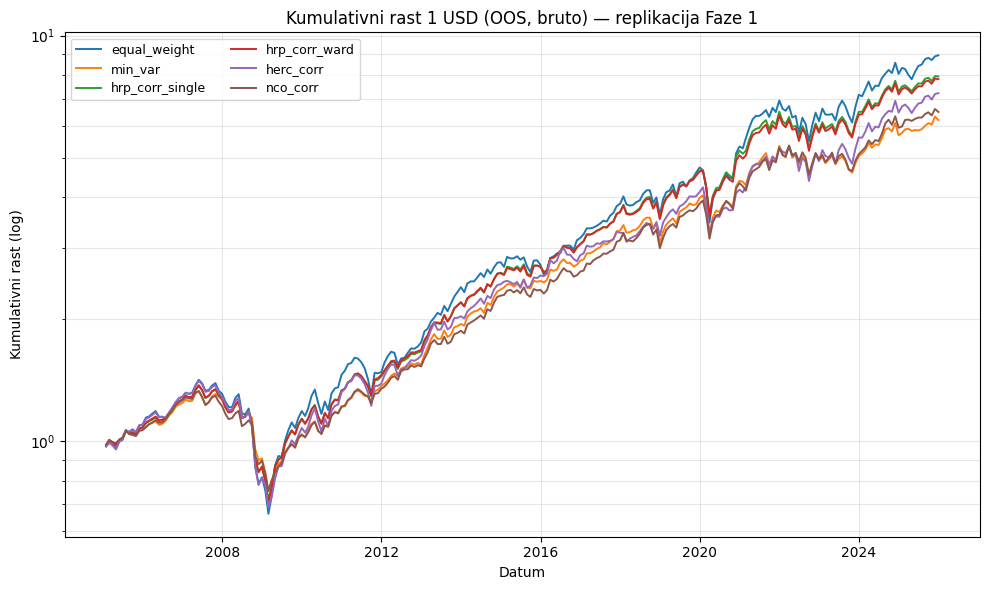

In [7]:
plot_names = [
    "equal_weight",
    "min_var",
    "hrp_corr_single",
    "hrp_corr_ward",
    "herc_corr",
    "nco_corr",
]
plot_names = [name for name in plot_names if name in gross_panel.columns]

growth = (1.0 + gross_panel[plot_names]).cumprod()

fig, ax = plt.subplots(figsize=(10, 6))
for name in plot_names:
    ax.plot(growth.index, growth[name], label=name, linewidth=1.4)
ax.set_yscale("log")
ax.set_title("Kumulativni rast 1 USD (OOS, bruto) — replikacija Faze 1")
ax.set_xlabel("Datum")
ax.set_ylabel("Kumulativni rast (log)")
ax.legend(loc="upper left", ncol=2, fontsize=9)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_cumulative_growth.png", dpi=150)
plt.show()
